# Día 8 · Unidad 8 — Visualización (I): Matplotlib básico

**Objetivos de aprendizaje**
- Entender la jerarquía de objetos de Matplotlib: `Figure` → `Axes` → `Axis`.
- Distinguir el enfoque *stateful* (`pyplot` implícito) del *stateless* (`Figure`/`Axes` explícitos), y por qué este curso usa el segundo.
- Crear gráficos con `plt.subplots()`, con uno o varios `Axes` a la vez.
- Gestionar la memoria de `Figure`s (por qué y cuándo cerrarlas).

**Duración estimada:** 75-90 minutos.

**Requisitos previos:** Día 7 y `01`-`02` de este mismo día (pandas). No hace falta ninguna base previa de visualización.

## 1. Por qué Matplotlib puede resultar confuso al principio

[Matplotlib](https://matplotlib.org/) es la librería base de visualización en Python — casi todo lo demás (incluido seaborn, que veréis después) está construido encima. No es difícil por falta de documentación (la tiene, y muy extensa), sino por tres motivos concretos:

- Es una librería enorme (~70.000 líneas de código).
- Ofrece **varias interfaces distintas** para construir el mismo gráfico, y puede usar varios "backends" (cómo se renderiza realmente la imagen).
- Ha evolucionado mucho: ejemplos antiguos en internet pueden usar 3-4 veces más código del que hace falta hoy.

Antes de los ejemplos, conviene fijar los conceptos básicos de su diseño — el resto encaja mucho mejor una vez entendida la jerarquía de objetos.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cartera = pd.read_csv("../data/raw/cartera_polizas.csv")
cartera[["edad_tomador", "producto", "prima_anual", "franquicia"]].head()

,edad_tomador,producto,prima_anual,franquicia
0,60,AUTO,455.69,450
1,54,HOGAR,274.72,300
2,22,HOGAR,207.32,150
3,68,AUTO,540.71,300
4,76,AUTO,589.46,450


## 2. La jerarquía de objetos de Matplotlib

Un gráfico de Matplotlib es, por dentro, un árbol de objetos anidados:

- **`Figure`**: el contenedor más externo — la "hoja de papel" o "ventana" completa. Puede contener uno o varios gráficos.
- **`Axes`**: un gráfico individual dentro de la `Figure` (no confundir con `Axis`, en singular — es un error de nombres heredado de MATLAB, pero hay que acostumbrarse).
  - **`Axis`**: los ejes vertical y horizontal de un `Axes` concreto.
  - `Title`, leyenda, etc.: elementos dentro de un `Axes`.

Podéis comprobarlo con código:

<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>


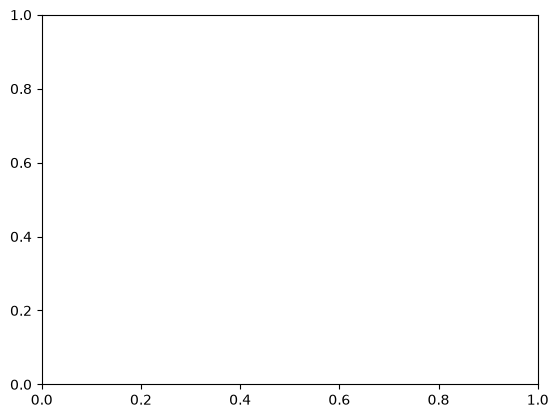

In [2]:
fig, ax = plt.subplots()
print(type(fig))
print(type(ax))

In [3]:
# Recorriendo la jerarquía con notación de atributos
print(fig.axes[0] is ax)   # el Axes que creamos está dentro de fig.axes
print(type(ax.yaxis))      # el Axis vertical de ese Axes
plt.close(fig)

True
<class 'matplotlib.axis.YAxis'>


## 3. *Stateful* vs. *stateless*

La mayoría de funciones de `pyplot` (`plt.plot()`, `plt.title()`...) se refieren **implícitamente** a la `Figure` y el `Axes` "actuales" — los crean si no existen, o los reutilizan si ya existen. Esto es el enfoque ***stateful***: no nombráis explícitamente sobre qué gráfico estáis trabajando, Matplotlib lo adivina a partir del último que tocasteis.

El enfoque ***stateless*** consiste en crear explícitamente `Figure` y `Axes`, y llamar a los métodos **sobre esas instancias concretas** (`ax.plot(...)`, `ax.set_title(...)`), en vez de sobre `pyplot` directamente.

**En este curso usaremos siempre el enfoque *stateless*.** Es un poco más verboso al principio, pero da control total sobre qué `Axes` concreto se está modificando — imprescindible en cuanto tenéis más de un gráfico en la misma `Figure` (que es prácticamente siempre, en un informe real).

> ⚠️ **Error típico**: mezclar ambos enfoques sin darse cuenta — por ejemplo, crear `fig, (ax1, ax2) = plt.subplots(1, 2)` y luego llamar a `plt.title("...")` (en vez de `ax1.set_title("...")` o `ax2.set_title("...")`). `plt.title()` es *stateful*: afecta al "`Axes` actual", que con dos subgráficos puede no ser el que creíais. El resultado no da error, pero el título aparece en el gráfico equivocado (o en ninguno de los dos donde esperabais).

## 4. `plt.subplots()`: la puerta de entrada al enfoque *stateless*

La forma habitual (no muy intuitiva la primera vez: es una función de `pyplot`, pero se usa para **crear** las instancias `Figure`/`Axes` sobre las que luego trabajaréis de forma explícita) es `plt.subplots()`.

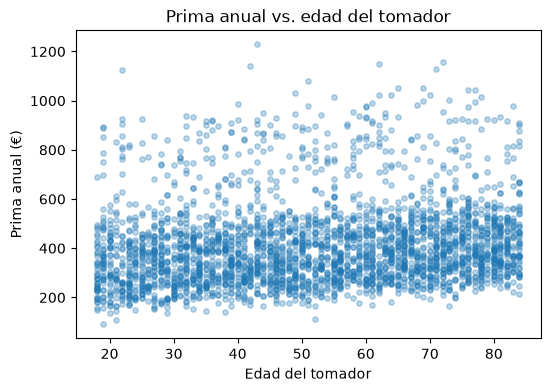

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))  # figsize en pulgadas (ancho, alto)

edad = cartera["edad_tomador"]
prima = cartera["prima_anual"]

ax.scatter(edad, prima, alpha=0.3, s=15)
ax.set_title("Prima anual vs. edad del tomador")
ax.set_xlabel("Edad del tomador")
ax.set_ylabel("Prima anual (€)")
plt.show()

`plt.subplots(nrows=1, ncols=1)` (los valores por defecto) da un único `Axes`. Con más de una fila/columna, `plt.subplots()` devuelve un **array** de `Axes` en vez de uno solo — hay que desempaquetarlo o indexarlo.

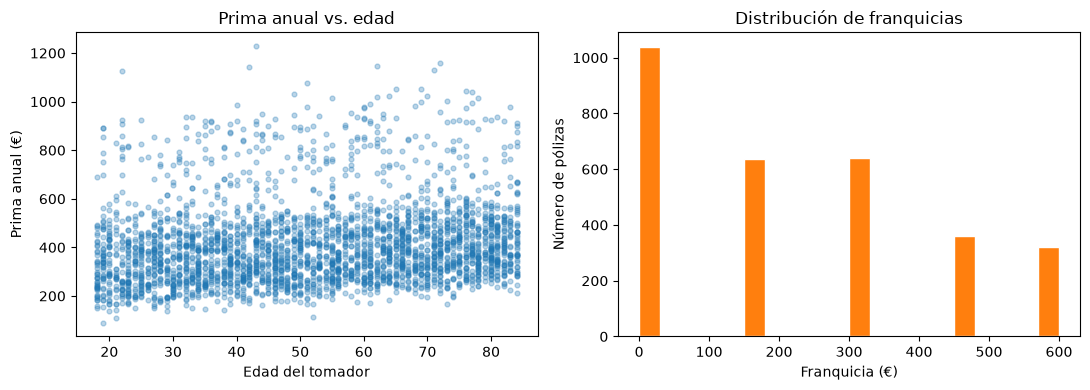

In [5]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(11, 4))

ax1.scatter(cartera["edad_tomador"], cartera["prima_anual"], alpha=0.3, s=12, c="tab:blue")
ax1.set_title("Prima anual vs. edad")
ax1.set_xlabel("Edad del tomador")
ax1.set_ylabel("Prima anual (€)")

ax2.hist(cartera["franquicia"], bins=20, color="tab:orange", edgecolor="white")
ax2.set_title("Distribución de franquicias")
ax2.set_xlabel("Franquicia (€)")
ax2.set_ylabel("Número de pólizas")

fig.tight_layout()  # ajusta los espacios para que los textos no se solapen
plt.show()

`fig.axes` da la lista de todos los `Axes` que contiene esa `Figure` — útil cuando tenéis muchos subgráficos y queréis iterar sobre ellos en vez de nombrarlos uno a uno:

In [6]:
print(f"Número de Axes en fig: {len(fig.axes)}")
print(fig.axes[0] is ax1, fig.axes[1] is ax2)

Número de Axes en fig: 2
True True


> 📊 **En Excel esto sería...** como la diferencia entre insertar un gráfico normal (un único `Axes` en una `Figure`) y crear un panel de varios gráficos en la misma hoja: en Excel se posicionan a mano, arrastrando cada uno; con `plt.subplots(nrows, ncols)` definís la cuadrícula de una vez y cada `Axes` ya sabe qué posición ocupa.

**Para ti:** con `plt.subplots(nrows=1, ncols=2)`, dibujad a la izquierda un histograma de `edad_tomador` y a la derecha un `scatter` de `franquicia` (eje X) vs. `prima_anual` (eje Y). Añadid título y etiquetas de eje a ambos — sin ellos, un gráfico no comunica nada por sí solo.

In [7]:
# Tu código aquí


## 5. Cuadrículas más flexibles: `plt.subplot2grid()`

Cuando la cuadrícula no es uniforme (un gráfico grande arriba, dos pequeños abajo, por ejemplo), `plt.subplot2grid()` da control fila a fila y columna a columna sobre cuánto espacio ocupa cada `Axes`.

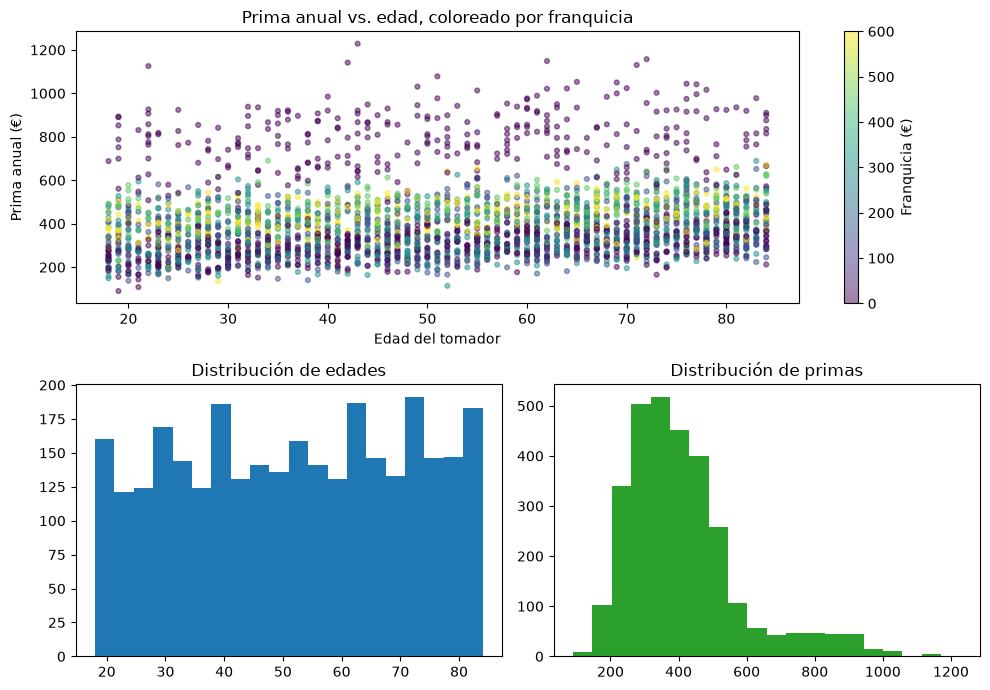

In [8]:
gridsize = (2, 2)
fig = plt.figure(figsize=(10, 7))

ax_grande = plt.subplot2grid(gridsize, (0, 0), colspan=2)  # ocupa toda la fila superior
ax_izq = plt.subplot2grid(gridsize, (1, 0))
ax_der = plt.subplot2grid(gridsize, (1, 1))

sctr = ax_grande.scatter(
    cartera["edad_tomador"], cartera["prima_anual"],
    c=cartera["franquicia"], cmap="viridis", alpha=0.5, s=12,
)
ax_grande.set_title("Prima anual vs. edad, coloreado por franquicia")
ax_grande.set_xlabel("Edad del tomador")
ax_grande.set_ylabel("Prima anual (€)")
fig.colorbar(sctr, ax=ax_grande, label="Franquicia (€)")

ax_izq.hist(cartera["edad_tomador"], bins=20, color="tab:blue")
ax_izq.set_title("Distribución de edades")

ax_der.hist(cartera["prima_anual"], bins=20, color="tab:green")
ax_der.set_title("Distribución de primas")

fig.tight_layout()
plt.show()

## 6. Gestión de memoria de `Figure`s

Cada `plt.subplots()` (o `plt.figure()`) crea una nueva `Figure` que Matplotlib mantiene en memoria mientras no se cierre explícitamente. En un notebook esto rara vez es un problema con dos o tres gráficos, pero en un script que genera muchas figuras en un bucle (por ejemplo, un gráfico por provincia de la cartera), acumular `Figure`s sin cerrarlas puede agotar la memoria.

In [9]:
print("Figuras abiertas antes de crear más:", plt.get_fignums())

fig_a, _ = plt.subplots()
fig_b, _ = plt.subplots()
print("Figuras abiertas ahora:", plt.get_fignums())

plt.close(fig_a)   # cierra una Figure concreta
print("Tras cerrar fig_a:", plt.get_fignums())

plt.close("all")   # cierra todas las Figures abiertas
print("Tras close('all'):", plt.get_fignums())

Figuras abiertas antes de crear más: []
Figuras abiertas ahora: [1, 2]
Tras cerrar fig_a: [2]
Tras close('all'): []


> ⚠️ **Error típico**: generar gráficos dentro de un bucle `for` sin cerrar la `Figure` de cada vuelta (`plt.close(fig)` al final, o `plt.close("all")` después del bucle). Con pocas iteraciones no se nota, pero generando decenas o cientos de figuras (por ejemplo, un gráfico de siniestralidad por cada una de las 50 provincias) el consumo de memoria crece sin límite y puede acabar en un `MemoryError` — un fallo que además solo aparece tarde, no en la primera iteración, lo que lo hace más difícil de diagnosticar.

**Para ti:** escribid un bucle `for` que cree y cierre 5 `Figure`s vacías (`plt.subplots()` seguido de `plt.close(fig)` en cada vuelta), comprobando con `plt.get_fignums()` antes y después del bucle que no queda ninguna abierta.

In [10]:
# Tu código aquí


## Resumen

- Un gráfico de Matplotlib es una jerarquía de objetos: `Figure` (el contenedor) → `Axes` (un gráfico individual) → `Axis` (los ejes X/Y de ese `Axes`).
- El enfoque ***stateful*** (`plt.plot()`, `plt.title()`...) opera implícitamente sobre la `Figure`/`Axes` "actual"; el enfoque ***stateless*** (`ax.plot()`, `ax.set_title()`) opera explícitamente sobre instancias concretas — este curso usa siempre el segundo, porque da control real en cuanto hay más de un gráfico.
- `plt.subplots(nrows, ncols)` crea la `Figure` y el/los `Axes` de golpe; con más de un `Axes`, devuelve un array que hay que desempaquetar o indexar.
- `plt.subplot2grid()` permite cuadrículas no uniformes (un gráfico grande, varios pequeños) cuando `plt.subplots()` se queda corto.
- `fig.tight_layout()` ajusta automáticamente los espacios para que títulos y etiquetas no se solapen entre subgráficos.
- Cerrad las `Figure`s que ya no necesitéis (`plt.close(fig)` o `plt.close("all")`), sobre todo dentro de bucles que generan muchos gráficos — si no, el consumo de memoria crece sin límite.

**Siguiente:** `04_teoria_seaborn_distribucion_categorica.ipynb`, donde pasamos a seaborn: gráficos estadísticos de alto nivel construidos sobre Matplotlib.